In [51]:
from pathlib import Path
import argparse
import json
import logging
import sqlite3
import tarfile
import os
import tempfile
from io import BytesIO
import struct
import logging
from dotenv import load_dotenv

from PIL import Image
from tqdm.auto import tqdm
import clip
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from union_find import UnionFind
from schema import DB
from schema import setup_db
from hotdog import initial_setup


%load_ext autoreload
%autoreload 2

load_dotenv()
setup_db()

DB = os.environ.get('DB', 'embedding.db')
FOOD_TAR_PATH = os.environ.get('FOOD_TAR_PATH')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
!uv add matplotlib

Resolved 137 packages in 5ms
Audited 118 packages in 5ms


In [50]:
!uv add scikit-learn

Resolved 141 packages in 210ms                                       
Installed 4 packages in 112ms                                    
 + joblib==1.5.3
 + scikit-learn==1.8.0
 + scipy==1.17.1
 + threadpoolctl==3.6.0


In [9]:
!uv pip install git+https://github.com/openai/CLIP.git

Resolved 19 packages in 502ms                                        
Uninstalled 1 package in 1ms
Installed 1 package in 2ms+https://github.com/openai/CLIP.gi
 - clip==0.2.0
 + clip==1.0 (from git+https://github.com/openai/CLIP.git@d05afc436d78f1c48dc0dbf8e5980a9d471f35f6)


In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
    
model, preprocess = clip.load("ViT-B/32", device=device)

In [21]:
%%time
df = initial_setup()

  0%|          | 0/101112 [00:00<?, ?it/s]

CPU times: user 16.1 s, sys: 2.5 s, total: 18.6 s
Wall time: 2min 3s


In [24]:
%%time
# Compute embeddings for all hot dogs.
with tarfile.open(FOOD_TAR_PATH, 'r:gz') as tar:
    for idx, row in tqdm(df[df['label'] == 'hot_dog'].iterrows()):
        member = tar.getmember(row['path'])
        with tar.extractfile(member) as member_file:
            image_file = BytesIO(member_file.read())
            image = preprocess(Image.open(image_file)).unsqueeze(0).to(device)
            with torch.no_grad():
                image_features = model.encode_image(image)
            v = image_features[0].cpu().numpy().tolist()
            with sqlite3.connect(DB) as conn:
                sql = 'UPDATE embeddings SET embedding = ? WHERE id = ?'
                conn.execute(sql, (struct.pack('512f', *v), row['id']))        

0it [00:00, ?it/s]

CPU times: user 32.6 s, sys: 4.15 s, total: 36.7 s
Wall time: 2min 22s


In [ ]:
with sqlite3.connect(DB) as conn:
    sql = "SELECT id FROM embeddings WHERE embedding IS NOT NULL AND model = 'clip'"
    known_ids = set(pd.read_sql(sql, conn)['id'].tolist())
print(len(known_ids))

In [26]:
%%time
# Compute embeddings for all images.
with tarfile.open(FOOD_TAR_PATH, 'r:gz') as tar:
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        if row['id'] in known_ids:
            continue
        member = tar.getmember(row['path'])
        try:
            with tar.extractfile(member) as member_file:
                image_file = BytesIO(member_file.read())
                image = preprocess(Image.open(image_file)).unsqueeze(0).to(device)
                with torch.no_grad():
                    image_features = model.encode_image(image)
                v = image_features[0].cpu().numpy().tolist()
                with sqlite3.connect(DB) as conn:
                    sql = 'UPDATE embeddings SET embedding = ? WHERE id = ?'
                    conn.execute(sql, (struct.pack('512f', *v), row['id']))        
        except Exception as ex:
            logging.error(ex)
            logging.error(row['path'])

  0%|          | 0/101000 [00:00<?, ?it/s]

CPU times: user 1.6 s, sys: 54.1 ms, total: 1.65 s
Wall time: 1.71 s


In [ ]:
with sqlite3.connect(DB) as conn:
    sql = "SELECT * FROM embeddings WHERE model = 'clip'"
    embeddings_df = pd.read_sql(sql, conn)
embeddings_df['embedding'] = embeddings_df['embedding'].map(lambda x: np.array(struct.unpack('512f', x)))
embeddings_df

In [28]:
def cosine_similarity(embedding1, embedding2):
    """Compute cosine similarity between two embeddings."""
    # Flatten embeddings if they are multidimensional
    emb1 = np.array(embedding1).flatten()
    emb2 = np.array(embedding2).flatten()

    # Compute cosine similarity
    dot_product = np.dot(emb1, emb2)
    norm1 = np.linalg.norm(emb1)
    norm2 = np.linalg.norm(emb2)

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot_product / (norm1 * norm2)

In [29]:
hotdog_df = embeddings_df[embeddings_df['label'] == 'hot_dog']
M = np.zeros([1000, 1000])
for i, v1 in enumerate(hotdog_df['embedding'].tolist()):
    for j, v2 in enumerate(hotdog_df['embedding'].tolist()):
        M[j][i] = cosine_similarity(v1, v2)

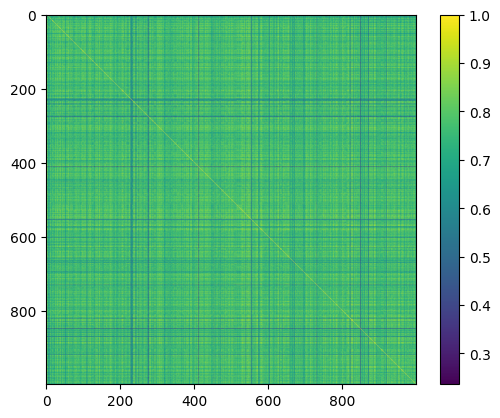

In [30]:
plt.imshow(M)
plt.colorbar()

In [31]:
with open('labels.txt') as f:
    label_txt = [l.strip() for l in f.readlines()]
with open('classes.txt') as f:
    classes_txt = [l.strip() for l in f.readlines()]    

In [34]:
text = clip.tokenize(label_txt).to(device)

with torch.no_grad():
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)

    logits_per_image, logits_per_text = model(image, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

In [35]:
classes_txt[np.argmax(probs)]

'hot_dog'

In [36]:
%%time
predictions = {}
for idx, row in tqdm(embeddings_df.iterrows(), total=len(embeddings_df)):
    v1 = row['embedding']
    sims = [cosine_similarity(v1, t.cpu().numpy())  for t in text_features]
    predictions[row['id']] = classes_txt[np.argmax(sims)]

  0%|          | 0/101000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
with sqlite3.connect(DB) as conn:
    sql = 'INSERT OR IGNORE INTO predictions (id, model, predicted_label) VALUES (?, ?, ?)'
    conn.executemany(sql, [(k, 'clip', v) for k, v in predictions.items()])

In [ ]:
%%time
with sqlite3.connect(DB) as conn:
    sql = '''
    SELECT embeddings.*, predicted_label 
    FROM embeddings
    LEFT JOIN predictions
        ON embeddings.id = predictions.id AND embeddings.model = predictions.model
    WHERE embeddings.model = 'clip'
    '''
    combined_df = pd.read_sql(sql, conn)
combined_df['embedding'] = combined_df['embedding'].map(lambda x: np.array(struct.unpack('512f', x)))
combined_df

In [ ]:
from sklearn.metrics import f1_score

accuracy = (combined_df['label'] == combined_df['predicted_label']).mean()
print(f'Overall accuracy: {accuracy:.4f}')

y_true = (combined_df['label'] == 'hot_dog').astype(int)
y_pred = (combined_df['predicted_label'] == 'hot_dog').astype(int)
print(f'Hot dog F1:       {f1_score(y_true, y_pred):.4f}')

mask = combined_df['label'] == 'hot_dog'
recall = (combined_df[mask]['label'] == combined_df[mask]['predicted_label']).mean()
print(f'Hot dog recall:   {recall:.4f}')

mask = combined_df['predicted_label'] == 'hot_dog'
precision = (combined_df[mask]['label'] == combined_df[mask]['predicted_label']).mean()
print(f'Hot dog precision:{precision:.4f}')

In [40]:
# False Negatives
mask = combined_df['label'] == 'hot_dog'
accuracy = (combined_df[mask]['label'] == combined_df[mask]['predicted_label']).sum() / len(combined_df[mask])
print(accuracy)
combined_df[mask].groupby('predicted_label').count().sort_values('id', ascending=False)

0.731


,id,path,label,embedding
predicted_label,,,,
hot_dog,731,731,731,731
lobster_roll_sandwich,84,84,84,84
pulled_pork_sandwich,54,54,54,54
club_sandwich,15,15,15,15
breakfast_burrito,11,11,11,11
grilled_cheese_sandwich,10,10,10,10
french_fries,10,10,10,10
falafel,8,8,8,8
poutine,6,6,6,6


In [41]:
# False Positives
mask = combined_df['predicted_label'] == 'hot_dog'
accuracy = (combined_df[mask]['label'] == combined_df[mask]['predicted_label']).sum() / len(combined_df[mask])
print(accuracy)
combined_df[mask].groupby('label').count().sort_values('id', ascending=False)

0.9643799472295514


,id,path,embedding,predicted_label
label,,,,
hot_dog,731,731,731,731
hamburger,8,8,8,8
pulled_pork_sandwich,4,4,4,4
chocolate_cake,2,2,2,2
lobster_roll_sandwich,2,2,2,2
beef_carpaccio,1,1,1,1
chicken_wings,1,1,1,1
club_sandwich,1,1,1,1
french_toast,1,1,1,1


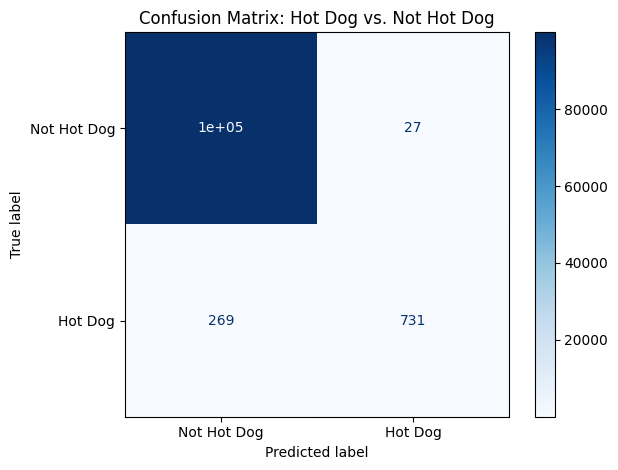

In [52]:
y_true = (combined_df['label'] == 'hot_dog').astype(int)
y_pred = (combined_df['predicted_label'] == 'hot_dog').astype(int)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Hot Dog', 'Hot Dog'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Hot Dog vs. Not Hot Dog')
plt.tight_layout()
plt.show()